# Circuit Breaker Performance Analysis

This notebook analyzes the results from the fault tolerance experiments.

## Experiments:
1. **Baseline** - No circuit breaker, no failures
2. **Baseline + Failures** - No circuit breaker, 30% payment failures
3. **Circuit Breaker** - Circuit breaker enabled, no failures
4. **Circuit Breaker + Failures** - Circuit breaker enabled, 30% payment failures

In [1]:
!pip install pandas matplotlib seaborn numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

In [2]:
# Find the most recent experiment results
results_dir = Path('../results')
experiment_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir() and d.name.startswith('experiment_')])

if experiment_dirs:
    latest_experiment = experiment_dirs[-1]
    print(f"Using results from: {latest_experiment}")
else:
    print("No experiment results found. Run the experiments first!")
    latest_experiment = None

Using results from: ../results/experiment_20251223_132843


In [3]:
def load_experiment_data(experiment_path):
    """Load all data for an experiment"""
    data = {
        'name': experiment_path.name,
        'stats': None,
        'history': None,
        'failures': None,
        'cb_metrics': None
    }
    
    # Load stats summary
    stats_file = experiment_path / 'locust_stats.csv'
    if stats_file.exists():
        data['stats'] = pd.read_csv(stats_file)
    
    # Load time-series history
    history_file = experiment_path / 'locust_stats_history.csv'
    if history_file.exists():
        data['history'] = pd.read_csv(history_file)
        if 'Timestamp' in data['history'].columns:
            data['history']['Timestamp'] = pd.to_datetime(data['history']['Timestamp'], unit='s')
    
    # Load failures
    failures_file = experiment_path / 'locust_failures.csv'
    if failures_file.exists():
        data['failures'] = pd.read_csv(failures_file)
    
    # Load circuit breaker metrics
    cb_file = experiment_path / 'cb_metrics.json'
    if cb_file.exists():
        with open(cb_file) as f:
            try:
                data['cb_metrics'] = json.load(f)
            except:
                pass
    
    return data

In [4]:
# Load all experiments
experiments = {}

if latest_experiment:
    for exp_dir in sorted(latest_experiment.iterdir()):
        if exp_dir.is_dir():
            experiments[exp_dir.name] = load_experiment_data(exp_dir)
            print(f"Loaded: {exp_dir.name}")

print(f"\nTotal experiments loaded: {len(experiments)}")

Loaded: 1_baseline
Loaded: 2_baseline_failures
Loaded: 3_circuit_breaker
Loaded: 4_circuit_breaker_failures

Total experiments loaded: 4


## 1. Summary Statistics Comparison

In [5]:
# Extract key metrics from each experiment
summary_data = []

for name, data in experiments.items():
    if data['stats'] is not None:
        # Get the 'Aggregated' row
        agg = data['stats'][data['stats']['Name'] == 'Aggregated']
        if not agg.empty:
            row = agg.iloc[0]
            summary_data.append({
                'Experiment': name,
                'Total Requests': row.get('Request Count', 0),
                'Failure Count': row.get('Failure Count', 0),
                'Failure Rate (%)': row.get('Failure Count', 0) / max(row.get('Request Count', 1), 1) * 100,
                'Avg Response (ms)': row.get('Average Response Time', 0),
                'p50 (ms)': row.get('50%', 0),
                'p95 (ms)': row.get('95%', 0),
                'p99 (ms)': row.get('99%', 0),
                'RPS': row.get('Requests/s', 0)
            })

summary_df = pd.DataFrame(summary_data)
summary_df

,Experiment,Total Requests,Failure Count,Failure Rate (%),Avg Response (ms),p50 (ms),p95 (ms),p99 (ms),RPS
0,1_baseline,23324,0,0.000000,3176.657194,2600,6900,10000,12.976632
1,2_baseline_failures,22645,294,1.298300,3374.566117,2800,7100,10000,12.591086
2,3_circuit_breaker,29116,0,0.000000,1638.926339,860,5900,9900,16.189788
3,4_circuit_breaker_failures,34649,472,1.362233,653.719688,440,2000,3400,19.263733


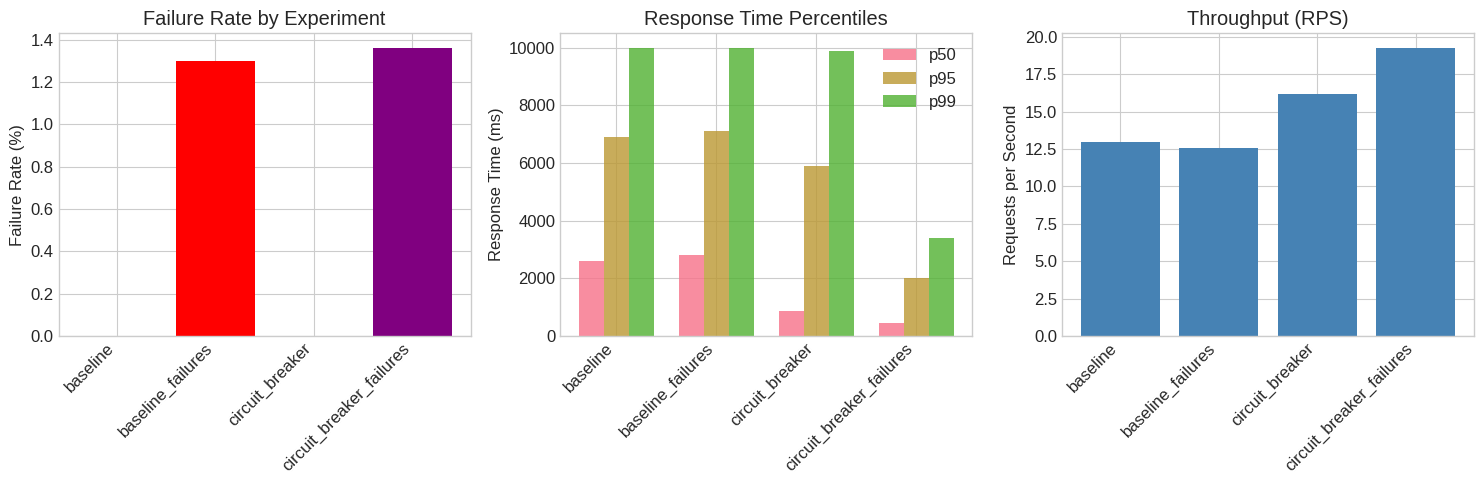

In [6]:
# Plot: Failure Rate Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Failure Rate
ax1 = axes[0]
colors = ['green' if 'baseline' in x and 'failures' not in x else 
          'red' if 'failures' in x and 'circuit' not in x else
          'blue' if 'circuit' in x and 'failures' not in x else
          'purple' for x in summary_df['Experiment']]
ax1.bar(range(len(summary_df)), summary_df['Failure Rate (%)'], color=colors)
ax1.set_xticks(range(len(summary_df)))
ax1.set_xticklabels([x.split('_', 1)[1] if '_' in x else x for x in summary_df['Experiment']], rotation=45, ha='right')
ax1.set_ylabel('Failure Rate (%)')
ax1.set_title('Failure Rate by Experiment')

# Response Time
ax2 = axes[1]
x = range(len(summary_df))
width = 0.25
ax2.bar([i - width for i in x], summary_df['p50 (ms)'], width, label='p50', alpha=0.8)
ax2.bar([i for i in x], summary_df['p95 (ms)'], width, label='p95', alpha=0.8)
ax2.bar([i + width for i in x], summary_df['p99 (ms)'], width, label='p99', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([x.split('_', 1)[1] if '_' in x else x for x in summary_df['Experiment']], rotation=45, ha='right')
ax2.set_ylabel('Response Time (ms)')
ax2.set_title('Response Time Percentiles')
ax2.legend()

# Throughput
ax3 = axes[2]
ax3.bar(range(len(summary_df)), summary_df['RPS'], color='steelblue')
ax3.set_xticks(range(len(summary_df)))
ax3.set_xticklabels([x.split('_', 1)[1] if '_' in x else x for x in summary_df['Experiment']], rotation=45, ha='right')
ax3.set_ylabel('Requests per Second')
ax3.set_title('Throughput (RPS)')

plt.tight_layout()
plt.savefig('summary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Time-Series Analysis

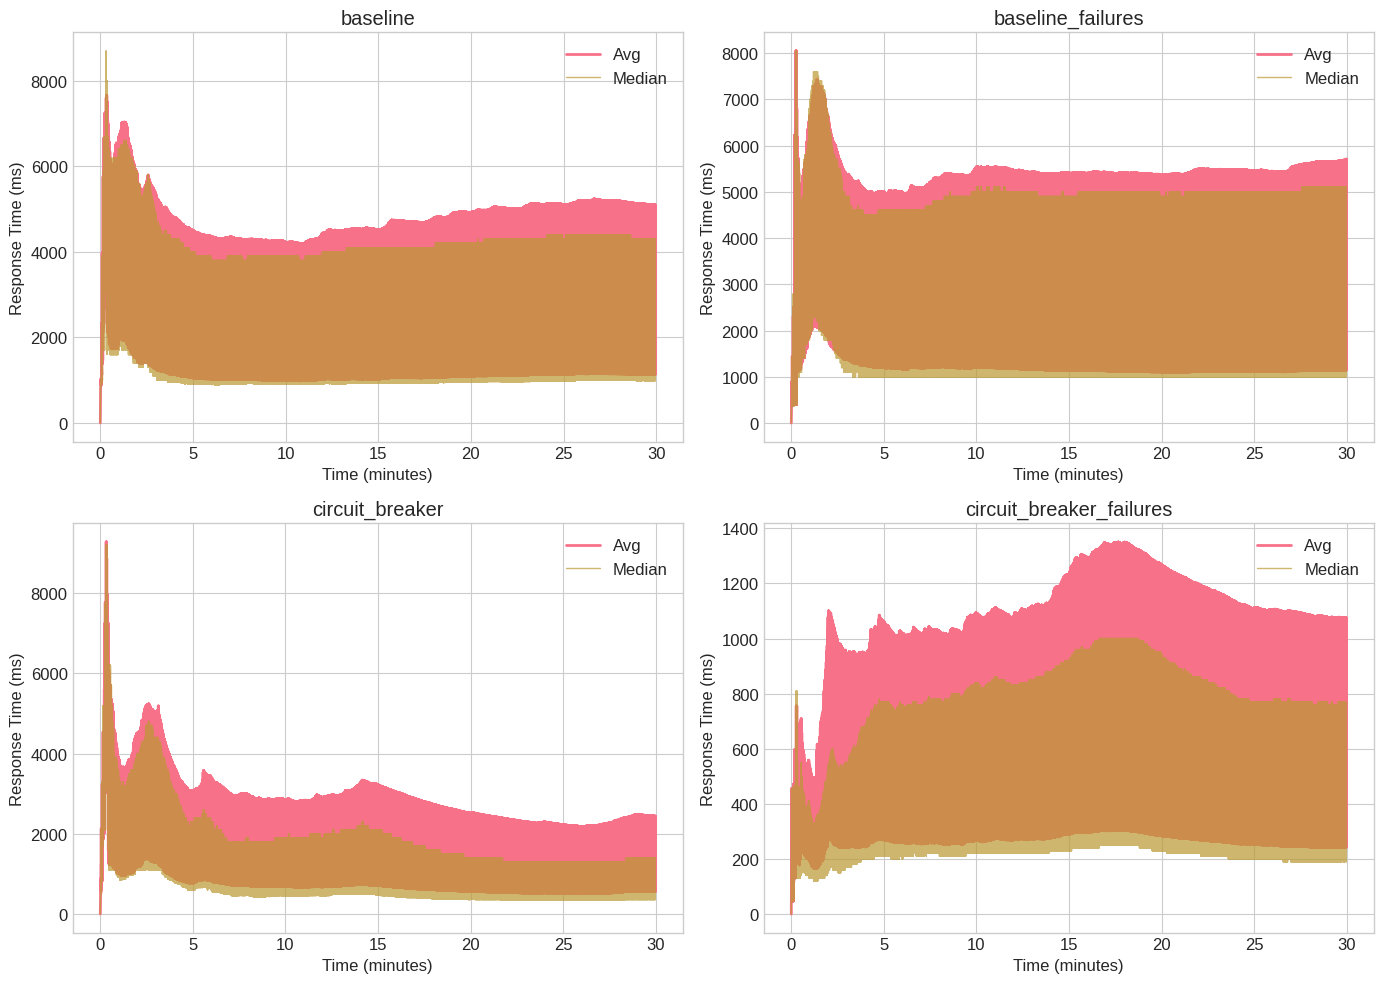

In [7]:
# Plot response time over time for each experiment
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, data) in enumerate(experiments.items()):
    if idx >= 4:
        break
    ax = axes[idx]
    
    if data['history'] is not None and not data['history'].empty:
        df = data['history'].copy()
        
        # Convert timestamp to elapsed minutes
        if 'Timestamp' in df.columns:
            df['Minutes'] = (df['Timestamp'] - df['Timestamp'].min()).dt.total_seconds() / 60
        else:
            df['Minutes'] = range(len(df))
        
        # Plot response times
        if 'Total Average Response Time' in df.columns:
            ax.plot(df['Minutes'], df['Total Average Response Time'], label='Avg', linewidth=2)
        if 'Total Median Response Time' in df.columns:
            ax.plot(df['Minutes'], df['Total Median Response Time'], label='Median', linewidth=1, alpha=0.7)
        if 'Total 95% Response Time' in df.columns:
            ax.plot(df['Minutes'], df['Total 95% Response Time'], label='p95', linewidth=1, alpha=0.7)
        
        ax.set_xlabel('Time (minutes)')
        ax.set_ylabel('Response Time (ms)')
        ax.set_title(name.split('_', 1)[1] if '_' in name else name)
        ax.legend(loc='upper right')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name)

plt.tight_layout()
plt.savefig('response_time_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

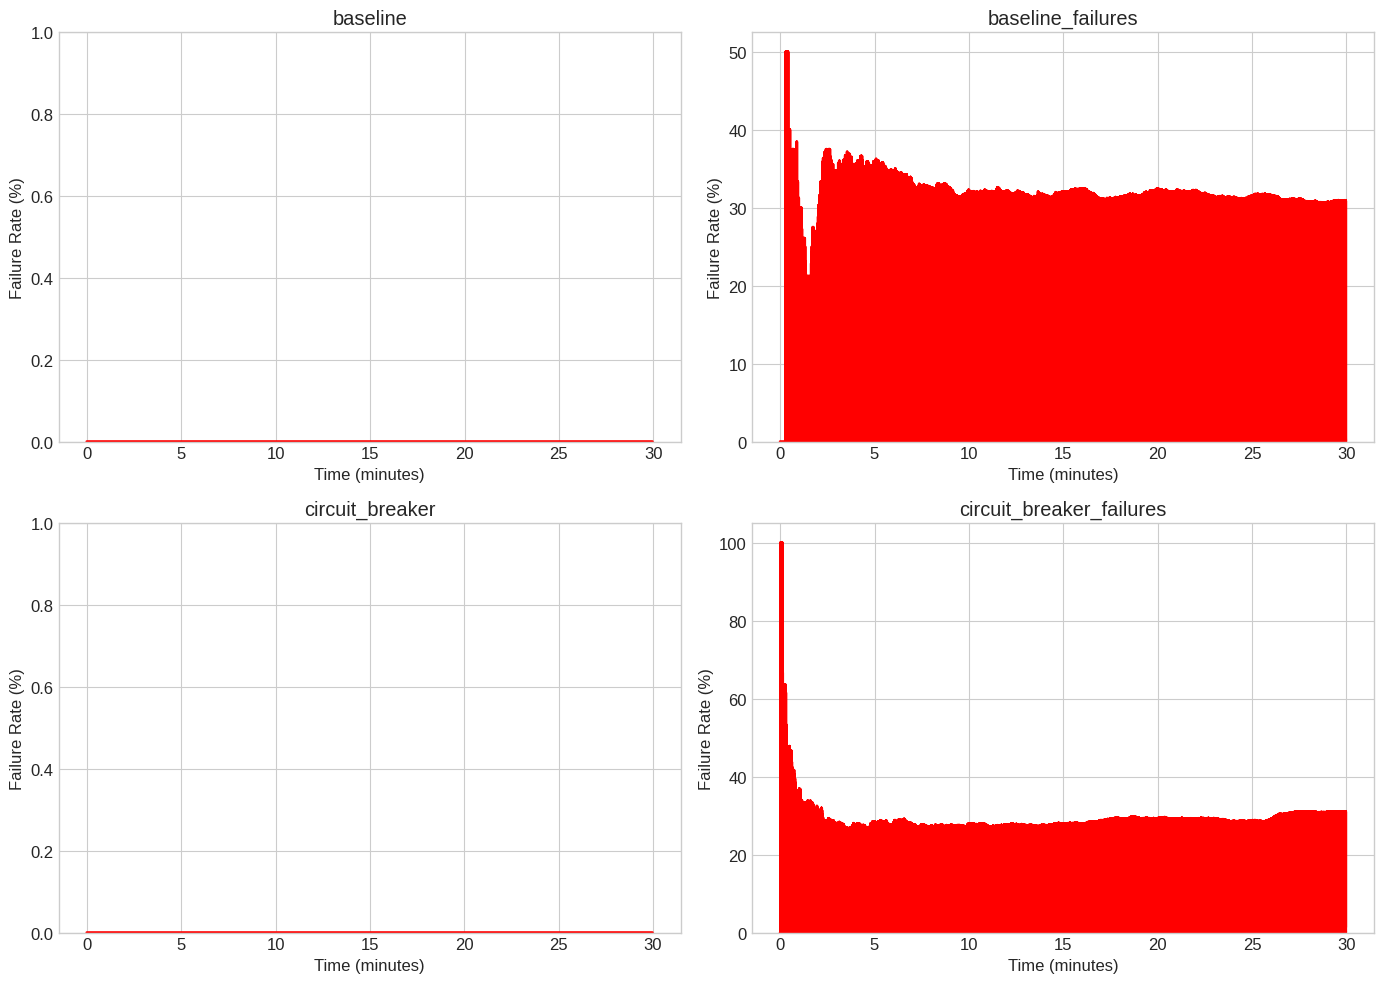

In [8]:
# Plot failure rate over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, data) in enumerate(experiments.items()):
    if idx >= 4:
        break
    ax = axes[idx]
    
    if data['history'] is not None and not data['history'].empty:
        df = data['history'].copy()
        
        if 'Timestamp' in df.columns:
            df['Minutes'] = (df['Timestamp'] - df['Timestamp'].min()).dt.total_seconds() / 60
        else:
            df['Minutes'] = range(len(df))
        
        # Calculate failure rate
        if 'Total Failure Count' in df.columns and 'Total Request Count' in df.columns:
            df['Failure Rate'] = df['Total Failure Count'] / df['Total Request Count'].replace(0, 1) * 100
            ax.plot(df['Minutes'], df['Failure Rate'], color='red', linewidth=2)
            ax.fill_between(df['Minutes'], df['Failure Rate'], alpha=0.3, color='red')
        
        ax.set_xlabel('Time (minutes)')
        ax.set_ylabel('Failure Rate (%)')
        ax.set_title(name.split('_', 1)[1] if '_' in name else name)
        ax.set_ylim(0, max(ax.get_ylim()[1], 1))
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name)

plt.tight_layout()
plt.savefig('failure_rate_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Circuit Breaker Metrics

In [9]:
# Analyze circuit breaker metrics
for name, data in experiments.items():
    print(f"\n{'='*50}")
    print(f"Experiment: {name}")
    print('='*50)
    
    if data['cb_metrics'] and 'breakers' in data['cb_metrics']:
        print(f"Circuit Breaker Enabled: {data['cb_metrics'].get('circuit_breaker_enabled', False)}")
        print("\nBreaker Statistics:")
        
        cb_summary = []
        for breaker_name, metrics in data['cb_metrics']['breakers'].items():
            cb_summary.append({
                'Service': breaker_name,
                'State': metrics.get('state', 'unknown'),
                'Total Calls': metrics.get('total_calls', 0),
                'Successes': metrics.get('total_successes', 0),
                'Failures': metrics.get('total_failures', 0),
                'Rejected': metrics.get('total_rejected', 0),
                'State Changes': len(metrics.get('state_changes', []))
            })
        
        cb_df = pd.DataFrame(cb_summary)
        display(cb_df)
        
        # Show state change timeline for breakers that had changes
        for breaker_name, metrics in data['cb_metrics']['breakers'].items():
            changes = metrics.get('state_changes', [])
            if changes:
                print(f"\n{breaker_name} state changes:")
                for change in changes:
                    print(f"  {change['from']} -> {change['to']} (failures: {change.get('failure_count', 'N/A')})")
    else:
        print("No circuit breaker metrics available")


Experiment: 1_baseline
Circuit Breaker Enabled: False

Breaker Statistics:


,Service,State,Total Calls,Successes,Failures,Rejected,State Changes
0,productcatalog,closed,0,0,0,0,0
1,cart,closed,0,0,0,0,0
2,currency,closed,0,0,0,0,0
3,shipping,closed,0,0,0,0,0
4,checkout,closed,0,0,0,0,0
5,recommendation,closed,0,0,0,0,0
6,ad,closed,0,0,0,0,0



Experiment: 2_baseline_failures
Circuit Breaker Enabled: False

Breaker Statistics:


,Service,State,Total Calls,Successes,Failures,Rejected,State Changes
0,productcatalog,closed,0,0,0,0,0
1,cart,closed,0,0,0,0,0
2,currency,closed,0,0,0,0,0
3,shipping,closed,0,0,0,0,0
4,checkout,closed,0,0,0,0,0
5,recommendation,closed,0,0,0,0,0
6,ad,closed,0,0,0,0,0



Experiment: 3_circuit_breaker
Circuit Breaker Enabled: True

Breaker Statistics:


,Service,State,Total Calls,Successes,Failures,Rejected,State Changes
0,productcatalog,closed,34752,34752,0,0,0
1,cart,closed,11315,11315,0,0,0
2,currency,closed,0,0,0,0,0
3,shipping,closed,7541,7541,0,0,0
4,checkout,closed,1267,1267,0,0,0
5,recommendation,closed,16341,16341,0,0,0
6,ad,closed,20323,20323,0,0,0



Experiment: 4_circuit_breaker_failures
Circuit Breaker Enabled: True

Breaker Statistics:


,Service,State,Total Calls,Successes,Failures,Rejected,State Changes
0,productcatalog,closed,47082,47082,0,0,0
1,cart,closed,13363,13363,0,0,0
2,currency,closed,0,0,0,0,0
3,shipping,closed,8956,8956,0,0,0
4,checkout,closed,1517,1045,446,26,3
5,recommendation,closed,19530,19530,0,0,0
6,ad,closed,24200,24200,0,0,0



checkout state changes:
  closed -> open (failures: 5)
  open -> half_open (failures: 5)
  half_open -> closed (failures: 0)


## 4. Key Findings Summary

In [10]:
# Generate summary table with key findings
if len(summary_df) >= 4:
    baseline = summary_df[summary_df['Experiment'].str.contains('1_baseline')].iloc[0] if len(summary_df[summary_df['Experiment'].str.contains('1_baseline')]) > 0 else None
    baseline_fail = summary_df[summary_df['Experiment'].str.contains('2_baseline_failures')].iloc[0] if len(summary_df[summary_df['Experiment'].str.contains('2_baseline_failures')]) > 0 else None
    cb_only = summary_df[summary_df['Experiment'].str.contains('3_circuit_breaker')].iloc[0] if len(summary_df[summary_df['Experiment'].str.contains('3_circuit_breaker')]) > 0 else None
    cb_fail = summary_df[summary_df['Experiment'].str.contains('4_circuit_breaker_failures')].iloc[0] if len(summary_df[summary_df['Experiment'].str.contains('4_circuit_breaker_failures')]) > 0 else None
    
    print("KEY FINDINGS")
    print("="*60)
    
    if baseline is not None and cb_only is not None:
        overhead = ((cb_only['Avg Response (ms)'] - baseline['Avg Response (ms)']) / baseline['Avg Response (ms)']) * 100
        print(f"\n1. Circuit Breaker Overhead (no failures):")
        print(f"   Response time impact: {overhead:+.2f}%")
        print(f"   Baseline avg: {baseline['Avg Response (ms)']:.2f}ms")
        print(f"   With CB avg: {cb_only['Avg Response (ms)']:.2f}ms")
    
    if baseline_fail is not None and cb_fail is not None:
        print(f"\n2. Failure Handling Comparison (30% payment failures):")
        print(f"   Without CB - Failure Rate: {baseline_fail['Failure Rate (%)']:.2f}%")
        print(f"   With CB    - Failure Rate: {cb_fail['Failure Rate (%)']:.2f}%")
        improvement = baseline_fail['Failure Rate (%)'] - cb_fail['Failure Rate (%)']
        print(f"   Improvement: {improvement:.2f} percentage points")
    
    if baseline_fail is not None and cb_fail is not None:
        print(f"\n3. Response Time Under Failure:")
        print(f"   Without CB p95: {baseline_fail['p95 (ms)']:.2f}ms")
        print(f"   With CB p95:    {cb_fail['p95 (ms)']:.2f}ms")
    
    print("\n" + "="*60)

KEY FINDINGS

1. Circuit Breaker Overhead (no failures):
   Response time impact: -48.41%
   Baseline avg: 3176.66ms
   With CB avg: 1638.93ms

2. Failure Handling Comparison (30% payment failures):
   Without CB - Failure Rate: 1.30%
   With CB    - Failure Rate: 1.36%
   Improvement: -0.06 percentage points

3. Response Time Under Failure:
   Without CB p95: 7100.00ms
   With CB p95:    2000.00ms



In [11]:
# Save summary to CSV
if len(summary_df) > 0:
    summary_df.to_csv('experiment_summary.csv', index=False)
    print("Summary saved to experiment_summary.csv")

Summary saved to experiment_summary.csv


## 5. Combined Visualization

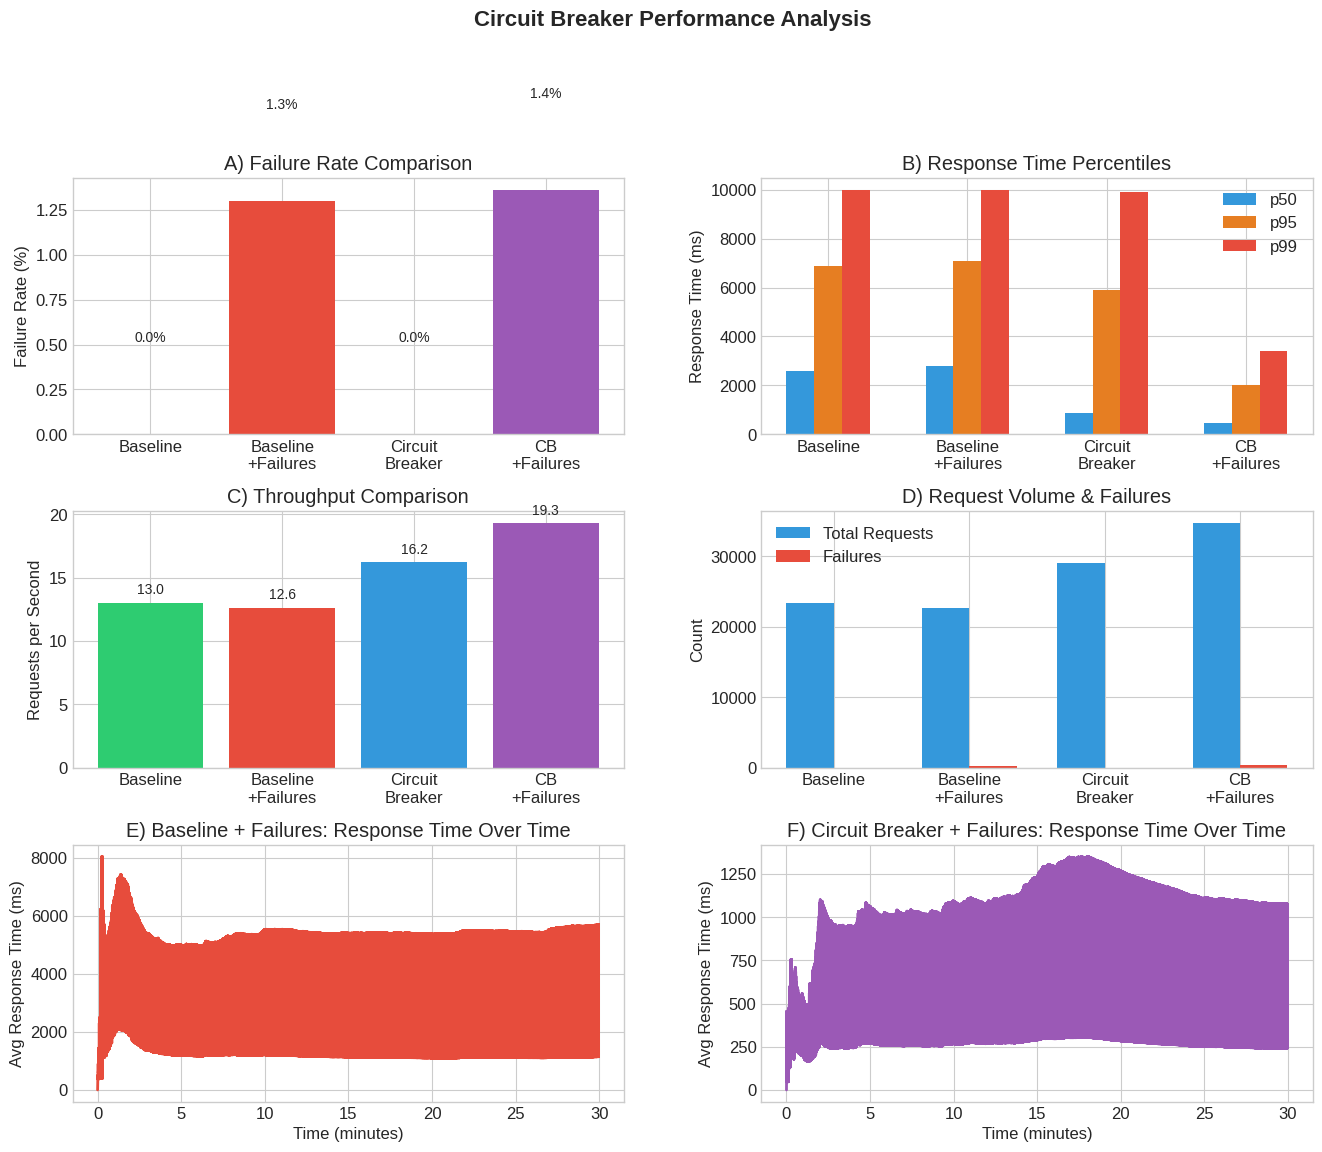

In [12]:
# Create a comprehensive comparison figure
fig = plt.figure(figsize=(16, 12))

# Create grid
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.25)

# 1. Failure Rate Bar Chart
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']
bars = ax1.bar(range(len(summary_df)), summary_df['Failure Rate (%)'], color=colors[:len(summary_df)])
ax1.set_xticks(range(len(summary_df)))
ax1.set_xticklabels(['Baseline', 'Baseline\n+Failures', 'Circuit\nBreaker', 'CB\n+Failures'][:len(summary_df)])
ax1.set_ylabel('Failure Rate (%)')
ax1.set_title('A) Failure Rate Comparison')
for bar, val in zip(bars, summary_df['Failure Rate (%)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=10)

# 2. Response Time Comparison
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(summary_df))
width = 0.2
ax2.bar(x - width, summary_df['p50 (ms)'], width, label='p50', color='#3498db')
ax2.bar(x, summary_df['p95 (ms)'], width, label='p95', color='#e67e22')
ax2.bar(x + width, summary_df['p99 (ms)'], width, label='p99', color='#e74c3c')
ax2.set_xticks(x)
ax2.set_xticklabels(['Baseline', 'Baseline\n+Failures', 'Circuit\nBreaker', 'CB\n+Failures'][:len(summary_df)])
ax2.set_ylabel('Response Time (ms)')
ax2.set_title('B) Response Time Percentiles')
ax2.legend()

# 3. Throughput
ax3 = fig.add_subplot(gs[1, 0])
bars = ax3.bar(range(len(summary_df)), summary_df['RPS'], color=colors[:len(summary_df)])
ax3.set_xticks(range(len(summary_df)))
ax3.set_xticklabels(['Baseline', 'Baseline\n+Failures', 'Circuit\nBreaker', 'CB\n+Failures'][:len(summary_df)])
ax3.set_ylabel('Requests per Second')
ax3.set_title('C) Throughput Comparison')
for bar, val in zip(bars, summary_df['RPS']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=10)

# 4. Total Requests vs Failures
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(summary_df))
width = 0.35
ax4.bar(x - width/2, summary_df['Total Requests'], width, label='Total Requests', color='#3498db')
ax4.bar(x + width/2, summary_df['Failure Count'], width, label='Failures', color='#e74c3c')
ax4.set_xticks(x)
ax4.set_xticklabels(['Baseline', 'Baseline\n+Failures', 'Circuit\nBreaker', 'CB\n+Failures'][:len(summary_df)])
ax4.set_ylabel('Count')
ax4.set_title('D) Request Volume & Failures')
ax4.legend()

# 5-6. Time series for two key experiments
if '2_baseline_failures' in experiments and experiments['2_baseline_failures']['history'] is not None:
    ax5 = fig.add_subplot(gs[2, 0])
    df = experiments['2_baseline_failures']['history'].copy()
    if 'Timestamp' in df.columns:
        df['Minutes'] = (df['Timestamp'] - df['Timestamp'].min()).dt.total_seconds() / 60
        if 'Total Average Response Time' in df.columns:
            ax5.plot(df['Minutes'], df['Total Average Response Time'], color='#e74c3c', linewidth=2)
        ax5.set_xlabel('Time (minutes)')
        ax5.set_ylabel('Avg Response Time (ms)')
        ax5.set_title('E) Baseline + Failures: Response Time Over Time')

if '4_circuit_breaker_failures' in experiments and experiments['4_circuit_breaker_failures']['history'] is not None:
    ax6 = fig.add_subplot(gs[2, 1])
    df = experiments['4_circuit_breaker_failures']['history'].copy()
    if 'Timestamp' in df.columns:
        df['Minutes'] = (df['Timestamp'] - df['Timestamp'].min()).dt.total_seconds() / 60
        if 'Total Average Response Time' in df.columns:
            ax6.plot(df['Minutes'], df['Total Average Response Time'], color='#9b59b6', linewidth=2)
        ax6.set_xlabel('Time (minutes)')
        ax6.set_ylabel('Avg Response Time (ms)')
        ax6.set_title('F) Circuit Breaker + Failures: Response Time Over Time')

plt.suptitle('Circuit Breaker Performance Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('comprehensive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()